<a href="https://colab.research.google.com/github/dewshishir/new-practice/blob/main/building_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/low cost"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class FastDataset(Dataset):
    def __init__(self, img_paths, mask_paths):
        self.imgs = img_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)

        h, w = img.shape[:2]

        # Random crop coordinates
        x = np.random.randint(0, w - 480)
        y = np.random.randint(0, h - 480)

        img = img[y:y+480, x:x+480]
        mask = mask[y:y+480, x:x+480]

        mask = (mask > 127).astype("float32")

        img = torch.tensor(img.transpose(2,0,1)).float()/255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
def collect(img_dir, mask_dir):
    imgs = sorted([os.path.join(img_dir,f) for f in os.listdir(img_dir)])
    masks = sorted([os.path.join(mask_dir,f) for f in os.listdir(mask_dir)])
    return imgs, masks

# WHU
w_img, w_mask = collect(
    BASE + "/WHU Building Dataset/train/Image",
    BASE + "/WHU Building Dataset/train/Mask"
)

# Massachusetts
m_img, m_mask = collect(
    BASE + "/Massachusetts Building Dataset/png/train",
    BASE + "/Massachusetts Building Dataset/png/train_labels"
)

# EAII (whole area)
e_img, e_mask = collect(
    BASE + "/Satellite dataset II (East Asia)/3. The whole area image/image",
    BASE + "/Satellite dataset II (East Asia)/3. The whole area image/label"
)

all_imgs = w_img + m_img + e_img
all_masks = w_mask + m_mask + e_mask

WHU: 4
MBD: 4
EAII: 0
Total: 4


In [ ]:
dataset = FastDataset(all_imgs, all_masks)

loader = DataLoader(
    dataset,
    batch_size=8,      # increase for T4
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import segmentation_models_pytorch as smp

device = "cuda"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

In [ ]:
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2.*intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def loss_fn(pred, mask):
    return bce(pred, mask) + dice_loss(pred, mask)

In [ ]:
from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.Adam(model.parameters(), lr=4e-5)
scaler = GradScaler()

/tmp/ipython-input-225/2805790853.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
for epoch in range(5):   # small epochs for colab
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(imgs)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")

Epoch 1 | Loss: 1.3012


/tmp/ipython-input-225/3484020211.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2 | Loss: 1.2841
Epoch 3 | Loss: 1.2722
Epoch 4 | Loss: 1.2505
Epoch 5 | Loss: 1.2401


In [ ]:
model.eval()

total_iou = 0
count = 0

with torch.no_grad():
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        preds = torch.sigmoid(outputs) > 0.5

        intersection = (preds & masks.bool()).float().sum((1,2,3))
        union = (preds | masks.bool()).float().sum((1,2,3))

        iou = (intersection + 1e-6) / (union + 1e-6)

        total_iou += iou.sum().item()
        count += iou.size(0)

print("Average IoU:", total_iou / count)

Average IoU: 0.08512946963310242


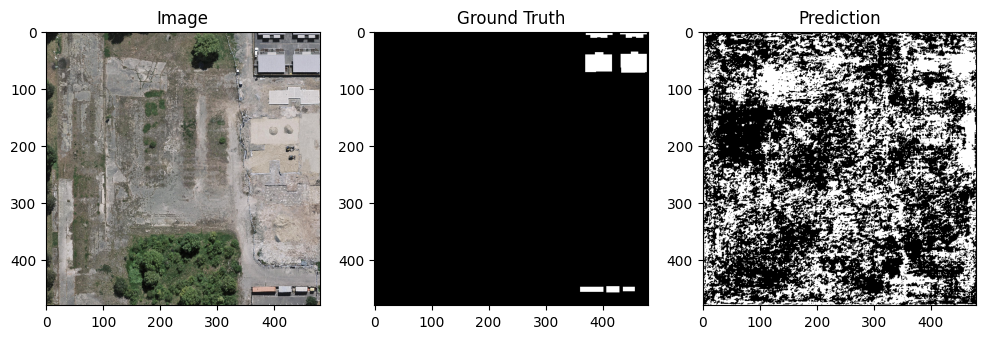

In [ ]:
import matplotlib.pyplot as plt

model.eval()

imgs, masks = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)
    preds = torch.sigmoid(outputs) > 0.5

img = imgs[0].cpu().permute(1,2,0)
mask = masks[0][0]
pred = preds[0][0].cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")

plt.show()